<a href="https://colab.research.google.com/github/NAHYEONKIM-nyo/DataAnalysis/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8B%9C%EC%A7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **3-1. 연도별 에너지 사용 총 사용량(전기+가스+수도+지역난방) 변화량을 선 그래프로 시각화하고, 그래프에 자신의 학번 뒤 4자리를 제목에 포함하여 저장하시오. (예: "연도별 에너지 사용 총액 변화 - 1234") 시각화 코드와 생성된 그래프를 첨부하시오. (4점)**

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

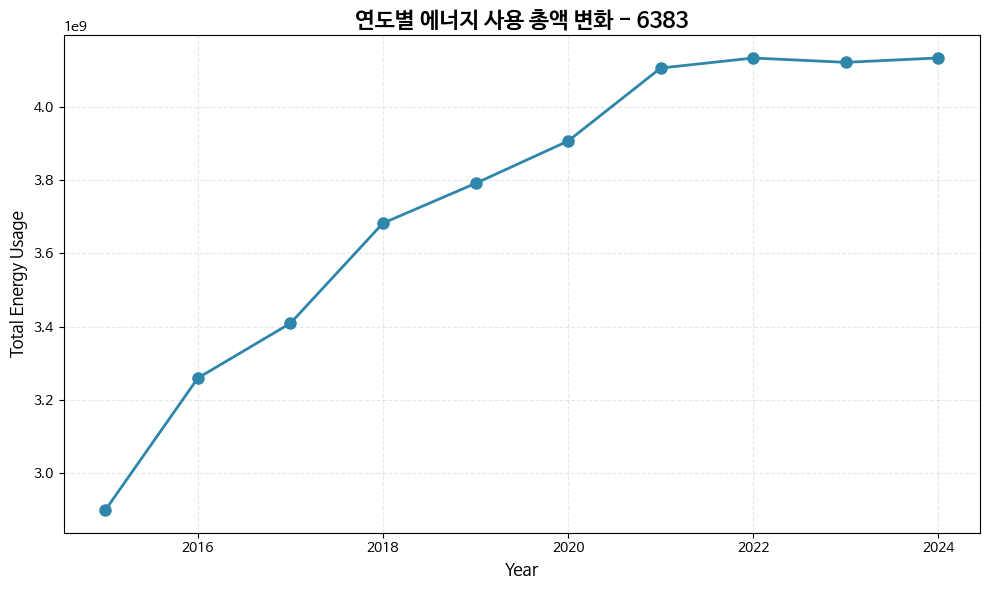

In [2]:
## 한국어 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

## 한국어 폰트 설정
plt.rc('font', family='NanumBarunGothic')

## 데이터 수집 url 및 api key 설정
url = 'http://openapi.seoul.go.kr:8088/5a774361516e61683733784e4b6978/json/energyUseDataSummaryInfo/1/1000/'
api_key = '5a774361516e61683733784e4b6978'
params = {
    'Key': api_key,
    'Type': 'json',
    'Service': 'energyUseDataSummaryInfo',
    'START_INDEX': '43',
    'END_INDEX': '882'
}

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()
original_data_list = data['energyUseDataSummaryInfo']['row']

## 날짜별 데이터를 담을 딕셔너리
date_keyed_data = {}
for item in original_data_list:
    year_int = int(item['YEAR'])
    mon_int = int(item['MON'])
    if item['MM_TYPE'] == '개인' and 2015 <= year_int <= 2024:
        key = f"{year_int}-{mon_int:02d}"
        value_dict = {
            'EUS': float(item['EUS']), 'GUS': float(item['GUS']),
            'WUS': float(item['WUS']), 'HUS': float(item['HUS'])
        }
        date_keyed_data[key] = value_dict
final_output = {'personal': date_keyed_data}

## json 파일 저장 (읽기 전에 저장 추가)
file_path = 'personal_energy_data.json'
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(final_output, f, ensure_ascii=False, indent=4)

## json 파일 열기
with open(file_path, 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

## 'personal'데이터를 Pandas DataFrame으로 변환
df = pd.DataFrame.from_dict(loaded_data['personal'], orient='index')

## 'month' 컬럼 생성
df['month'] = df.index.str[5:].astype(int)

## 'month'로 계절 분류
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:  # 12, 1, 2월
        return '겨울'

## 'year' 컬럼 추가
df['year'] = df.index.str[:4].astype(int)
## 'season' 컬럼 추가
df['season'] = df['month'].apply(get_season)
## 전처리에 사용된 'month' 컬럼 삭제
df = df.drop(columns='month')

# 연도별 총 에너지 사용량 라인 플롯

# 총 에너지 사용량 계산 (EUS + GUS + WUS + HUS)
df['total_energy'] = df['EUS'] + df['GUS'] + df['WUS'] + df['HUS']
# 연도별 총 에너지 사용량 계산
yearly_total = df.groupby('year')['total_energy'].sum()

# 라인 플롯 생성
plt.figure(figsize=(10, 6))
plt.plot(yearly_total.index, yearly_total.values, marker='o', linewidth=2, markersize=8, color='#2E86AB')
plt.title('연도별 에너지 사용 총액 변화 - 6383', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Energy Usage', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# 플롯 저장
plt.show()

#### **3-2. 계절별 가스 사용량 평균을 막대 그래프로 시각화하고, 각 막대에 구체적인 수치를 표시하시오. 시각화 코드와 생성된 그래프를 첨부하시오. (4점)**

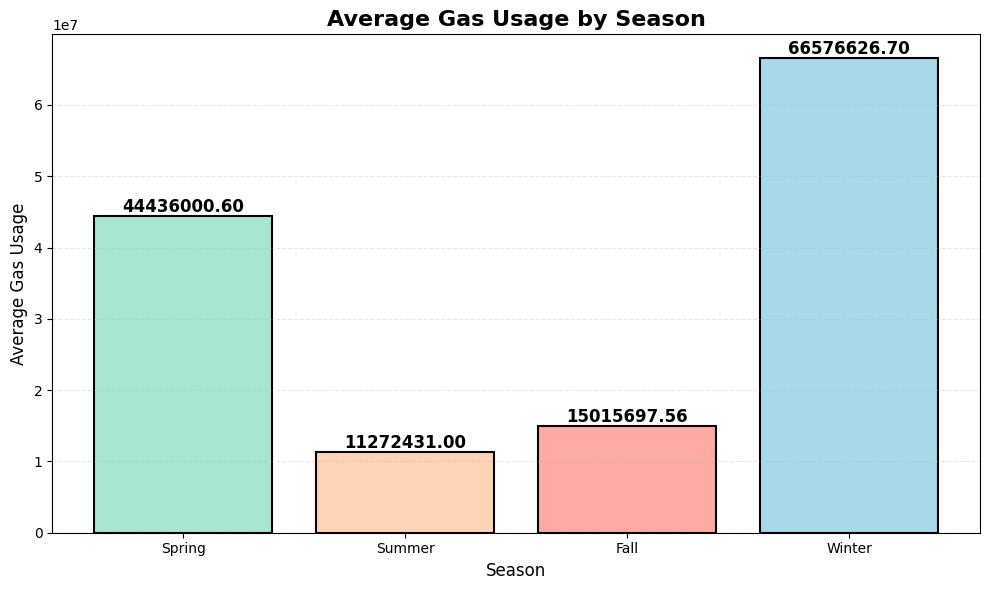

In [1]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

## 데이터 수집 url 및 api key 설정
url = 'http://openapi.seoul.go.kr:8088/5a774361516e61683733784e4b6978/json/energyUseDataSummaryInfo/1/1000/'
api_key = '5a774361516e61683733784e4b6978'
params = {
    'Key': api_key,
    'Type': 'json',
    'Service': 'energyUseDataSummaryInfo',
    'START_INDEX': '43',
    'END_INDEX': '882'
}

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()
original_data_list = data['energyUseDataSummaryInfo']['row']

## 날짜별 데이터를 담을 딕셔너리
date_keyed_data = {}
for item in original_data_list:
    year_int = int(item['YEAR'])
    mon_int = int(item['MON'])
    if item['MM_TYPE'] == '개인' and 2015 <= year_int <= 2024:
        key = f"{year_int}-{mon_int:02d}"
        value_dict = {
            'EUS': float(item['EUS']), 'GUS': float(item['GUS']),
            'WUS': float(item['WUS']), 'HUS': float(item['HUS'])
        }
        date_keyed_data[key] = value_dict
final_output = {'personal': date_keyed_data}

## json 파일 저장 (읽기 전에 저장 추가)
file_path = 'personal_energy_data.json'
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(final_output, f, ensure_ascii=False, indent=4)

## json 파일 열기
with open(file_path, 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

## 'personal'데이터를 Pandas DataFrame으로 변환
df = pd.DataFrame.from_dict(loaded_data['personal'], orient='index')

## 'month' 컬럼 생성
df['month'] = df.index.str[5:].astype(int)

## 'month'로 계절 분류
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:  # 12, 1, 2월
        return '겨울'

## 'year' 컬럼 추가
df['year'] = df.index.str[:4].astype(int)
## 'season' 컬럼 추가
df['season'] = df['month'].apply(get_season)
## 전처리에 사용된 'month' 컬럼 삭제
df = df.drop(columns='month')

# 계절별 평균 가스 사용량 바 플롯

# 계절별 평균 가스 사용량 계산
season_gas_avg = df.groupby('season')['GUS'].mean()

# 한글 계절명을 영어로 매핑
season_mapping = {'봄': 'Spring', '여름': 'Summer', '가을': 'Fall', '겨울': 'Winter'}
season_gas_avg_en = season_gas_avg.copy()
season_gas_avg_en.index = season_gas_avg_en.index.map(season_mapping)

# 계절 순서 재정렬
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_gas_avg_en = season_gas_avg_en.reindex(season_order)

# 바 플롯 생성
plt.figure(figsize=(10, 6))
bars = plt.bar(season_gas_avg_en.index, season_gas_avg_en.values, color=['#A8E6CF', '#FFD3B6', '#FFAAA5', '#A8D8EA'], edgecolor='black', linewidth=1.5)

# 각 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Average Gas Usage by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Gas Usage', fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# 플롯 저장
plt.show()